In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math

# Part 1: The "Prunable" Linear Layer

In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # Standard weights and biases
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        
        # Initialize bias
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

        nn.init.uniform_(self.gate_scores, 1.0, 2.0)

    def forward(self, x):
        # 1. Transform gate_scores to gates (0 to 1) via Sigmoid
        gates = torch.sigmoid(self.gate_scores)
        
        # 2. Calculate pruned weights
        pruned_weights = self.weight * gates
        
        # 3. Perform standard linear operation
        return F.linear(x, pruned_weights, self.bias)

In [4]:
# CNN feature extractor + Prunable Classifier

In [ ]:
class PrunableNetwork(nn.Module):
    def __init__(self):
        super(PrunableNetwork, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # prunable dense layers 
        self.classifier = nn.Sequential(
            PrunableLinear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            PrunableLinear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Part 2: Sparsity Regularization Loss

In [ ]:
def calculate_sparsity_loss(model):
  
    sparsity_loss = 0.0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            sparsity_loss += torch.sum(gates)
    return sparsity_loss

def calculate_sparsity_level(model, threshold=1e-2):
   
    total_weights = 0
    pruned_weights = 0
    
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores)
                total_weights += gates.numel()
                pruned_weights += torch.sum(gates < threshold).item()
                
    if total_weights == 0:
        return 0.0
    return (pruned_weights / total_weights) * 100

# Part 3: Training and Evaluation Loop

In [9]:
def train_and_evaluate(lambda_val, epochs=20, device='cuda'):
    print(f"\n{'='*40}\nTraining with Lambda: {lambda_val}\n{'='*40}")
    
    # Data Augmentation for CIFAR-10 to hit high accuracy
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    model = PrunableNetwork().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            classification_loss = criterion(outputs, labels)
            
            # Formulate Total Loss
            sparsity_loss = calculate_sparsity_loss(model)
            total_loss = classification_loss + (lambda_val * sparsity_loss)

            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()

        # Evaluate at end of epoch
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        sparsity_level = calculate_sparsity_level(model)
        scheduler.step(accuracy)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(trainloader):.4f} - Accuracy: {accuracy:.2f}% - Sparsity: {sparsity_level:.2f}%")

    return model, accuracy, sparsity_level

In [ ]:
def plot_gate_distribution(model):
    gate_values = []
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores).cpu().numpy().flatten()
                gate_values.extend(gates)
                
    plt.figure(figsize=(8, 5))
    plt.hist(gate_values, bins=50, color='skyblue', edgecolor='black')
    plt.title('Distribution of Gate Values')
    plt.xlabel('Gate Value (0 = Pruned, 1 = Kept)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


Training with Lambda: 0.0


100%|██████████| 170M/170M [00:34<00:00, 4.91MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Epoch [1/25] - Loss: 1.4511 - Accuracy: 59.44% - Sparsity: 0.00%
Epoch [2/25] - Loss: 1.1021 - Accuracy: 68.52% - Sparsity: 0.00%
Epoch [3/25] - Loss: 0.9748 - Accuracy: 71.22% - Sparsity: 0.00%
Epoch [4/25] - Loss: 0.9088 - Accuracy: 71.44% - Sparsity: 0.00%
Epoch [5/25] - Loss: 0.8477 - Accuracy: 70.04% - Sparsity: 0.00%
Epoch [6/25] - Loss: 0.8087 - Accuracy: 73.62% - Sparsity: 0.00%
Epoch [7/25] - Loss: 0.7739 - Accuracy: 74.01% - Sparsity: 0.00%
Epoch [8/25] - Loss: 0.7450 - Accuracy: 74.76% - Sparsity: 0.00%
Epoch [9/25] - Loss: 0.7272 - Accuracy: 77.20% - Sparsity: 0.00%
Epoch [10/25] - Loss: 0.7016 - Accuracy: 78.03% - Sparsity: 0.00%
Epoch [11/25] - Loss: 0.6814 - Accuracy: 76.89% - Sparsity: 0.00%
Epoch [12/25] - Loss: 0.6660 - Accuracy: 78.63% - Sparsity: 0.00%
Epoch [13/25] - Loss: 0.6481 - Accuracy: 79.36% - Sparsity: 0.00%
Epoch [14/25] - Loss: 0.6306 - Accuracy: 79.12% - Sparsity: 0.

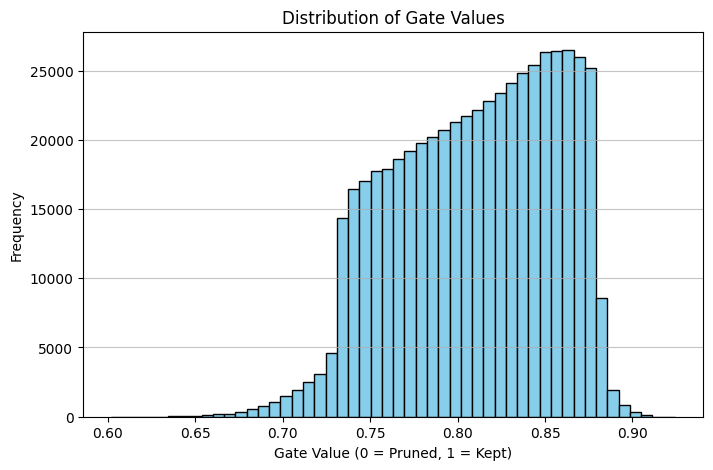

In [ ]:
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    lambdas = [0.0, 1e-5, 1e-4]
    results = []
    best_model = None
    best_accuracy = 0

    for l_val in lambdas:
        trained_model, final_acc, final_sparsity = train_and_evaluate(lambda_val=l_val, epochs=25, device=device)
        results.append((l_val, final_acc, final_sparsity))
        
        if final_acc > best_accuracy:
            best_accuracy = final_acc
            best_model = trained_model

    print("\n--- Final Results Summary ---")
    print(f"{'Lambda':<10} | {'Accuracy (%)':<15} | {'Sparsity Level (%)':<18}")
    print("-" * 50)
    for res in results:
        print(f"{res[0]:<10} | {res[1]:<15.2f} | {res[2]:<18.2f}")
        
    plot_gate_distribution(best_model)

## Why an L1 Penalty on Sigmoid Gates Encourages Sparsity?
In machine learning, L1 regularization geometrically constrains the parameter space in a way that encourages exact zero values,
unlike L2 regularization which only encourages small, near-zero values. In our architecture, the gate_scores are passed through a Sigmoid function, 
mapping them strictly to a range of (0, 1).By applying an L1 penalty directly to these post-sigmoid outputs (which acts as a simple summation since
the values are strictly positive), we force the optimizer to constantly push the gate values toward zero to minimize the total loss. When the 
classification_loss dictates that a specific weight is not heavily contributing to the correct prediction, the network will allow the L1 penalty to 
dominate that specific gate, pushing its value below our threshold and effectively severing (pruning) the connection.
